In [1]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize, curve_fit
from emcee import EnsembleSampler

import matplotlib.pyplot as plt

In [2]:
# df = pd.read_excel(r"Bell's Inequality Data.xlsx", "Tau")
df = pd.read_csv("tau_data.csv")
df['Actual Counts'] = df['Coincident Counts'] * 1000
df

,Dial Tau,Actual Tau?,Coincident Counts,Actual Counts
0,45.0,-7.00,0.093,93.0
1,46.0,-5.60,0.086,86.0
2,47.0,-4.20,0.082,82.0
3,48.0,-2.80,0.064,64.0
4,49.0,-1.40,0.080,80.0
...,...,...,...,...
61,76.6,37.24,0.113,113.0
62,76.8,37.52,0.092,92.0
63,77.0,37.80,0.092,92.0
64,77.0,37.80,0.114,114.0


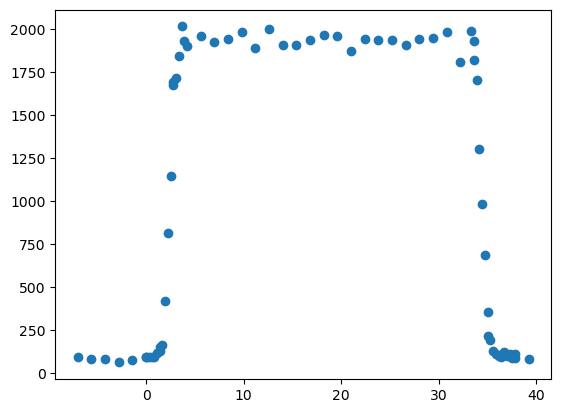

In [3]:
plt.scatter(df['Actual Tau?'], df['Actual Counts'])

In [4]:
def step_model(x, center, width, steepness, amplitude, noise):
    x = np.array(x)
    y = amplitude * np.exp(-((np.abs(x - center) / width)**steepness)) + noise
    return y

In [8]:
p0 = [20, 15, 60, 1800, 100]

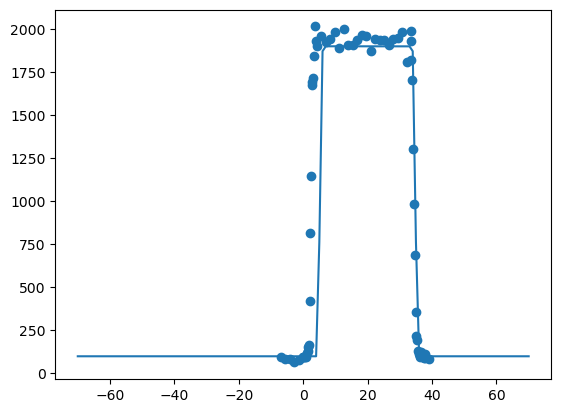

In [9]:
x = np.linspace(-70, 70, 141)
y = step_model(x, *p0)
plt.plot(x, y)
plt.scatter(df['Actual Tau?'], df['Actual Counts'])

In [13]:
def loss(theta):
    y_mod = step_model(df["Actual Tau?"], *theta)
    y_data = df["Actual Counts"]
    return np.sum((y_data - y_mod)**2/y_data)

In [22]:
opt_res = minimize(lambda p: loss(np.exp(p)), np.log(p0), method="Nelder-Mead")

# opt_res.x = np.exp(opt_res.x)
opt_res

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 242.87894448748614
             x: [ 2.913e+00  2.786e+00  3.610e+00  7.523e+00  4.603e+00]
           nit: 260
          nfev: 415
 final_simplex: (array([[ 2.913e+00,  2.786e+00, ...,  7.523e+00,
                         4.603e+00],
                       [ 2.913e+00,  2.786e+00, ...,  7.523e+00,
                         4.603e+00],
                       ...,
                       [ 2.913e+00,  2.786e+00, ...,  7.523e+00,
                         4.603e+00],
                       [ 2.913e+00,  2.786e+00, ...,  7.523e+00,
                         4.603e+00]], shape=(6, 5)), array([ 2.429e+02,  2.429e+02,  2.429e+02,  2.429e+02,
                        2.429e+02,  2.429e+02]))

(-20.0, 50.0)

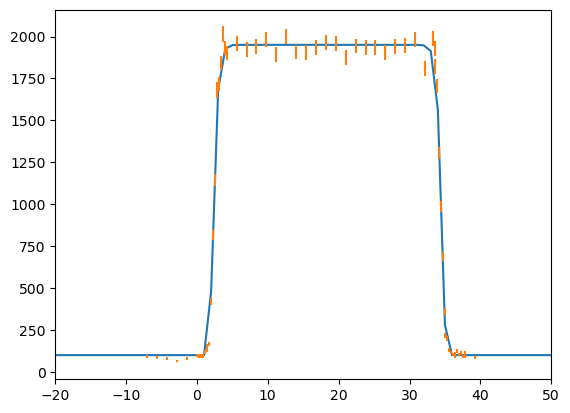

In [23]:
x = np.linspace(-70, 70, 141)
y = step_model(x, *np.exp(opt_res.x))
plt.plot(x, y)
plt.errorbar(df['Actual Tau?'], df['Actual Counts'], np.sqrt(df['Actual Counts']), ls="")
plt.xlim(-20, 50)

In [26]:
print("Actual physical parameters:")
param_labels = ["center", "width", "steepness", "amplitude", "noise"]
for label, val in zip(param_labels, np.exp(opt_res.x)):
    print(f"{label}: {val:.3f}")

Actual physical parameters:
center: 18.414
width: 16.210
steepness: 36.977
amplitude: 1850.578
noise: 99.794


In [32]:
def log_prior(theta):
    if np.any(theta < 0):
        return -np.inf
    
    return 0

def log_prob(theta):
    if log_prior(theta) == -np.inf:
        return -np.inf
    
    return -loss(theta)

In [33]:
N_WALKERS = 16

In [34]:
BUMP_SIZE = 1
x0 = np.exp(opt_res.x) + BUMP_SIZE * np.random.randn(N_WALKERS, len(opt_res.x))
x0

array([[  18.59870171,   17.96508989,   37.15073721, 1850.19574112,
          98.32837051],
       [  18.93308459,   15.87041915,   38.51967462, 1850.3159645 ,
          98.09131236],
       [  17.90295523,   15.74687903,   37.72224051, 1850.53509537,
         100.72580037],
       [  17.82740489,   17.10756327,   36.02811198, 1849.2642455 ,
          97.56910566],
       [  19.24722587,   15.50137953,   37.48946229, 1850.91560229,
         100.22499954],
       [  18.94948257,   15.85378883,   36.77507873, 1849.71590171,
          99.88045941],
       [  18.05869751,   17.55001683,   36.31983286, 1851.35476256,
          98.3424416 ],
       [  19.49741713,   15.29268861,   36.17211432, 1852.50834028,
          99.34809663],
       [  18.46487486,   15.82954188,   37.30679419, 1850.65694288,
          99.1983592 ],
       [  19.65971413,   16.65337405,   37.37554645, 1851.01170343,
         100.6384347 ],
       [  18.27763467,   16.85251416,   34.64779265, 1851.06133571,
          99

In [35]:
sampler = EnsembleSampler(N_WALKERS, x0.shape[1], log_prob)
sampler.run_mcmc(x0, 25_000, progress=True)

100%|██████████| 25000/25000 [01:30<00:00, 276.90it/s]


State([[  18.41281834   16.2138314    37.26963365 1844.95236488  100.56228208]
 [  18.41572582   16.21259134   36.63135126 1848.85839243   98.53730738]
 [  18.41569234   16.21135137   37.03077604 1852.1904067    98.48937231]
 [  18.40537609   16.20801516   36.43292246 1851.33466396  100.84302552]
 [  18.4231032    16.20317677   36.9478865  1854.92633804  100.67180897]
 [  18.41068857   16.21576788   36.87800931 1853.92800711   98.17770885]
 [  18.4147522    16.20590832   36.79741822 1850.63639645  102.33941807]
 [  18.41498967   16.21244694   36.93328654 1853.93694244   99.61664149]
 [  18.41491688   16.20745647   37.03643653 1844.00184555   99.52586733]
 [  18.41537808   16.20230346   36.99285866 1857.46838858  100.07112957]
 [  18.40936309   16.20874639   36.41919716 1842.73027409  100.35485541]
 [  18.41310278   16.20912648   36.04742537 1862.93786233   95.49136881]
 [  18.4164072    16.21748019   37.16708427 1855.15923202  100.53610123]
 [  18.4204067    16.21487014   36.43409095 1

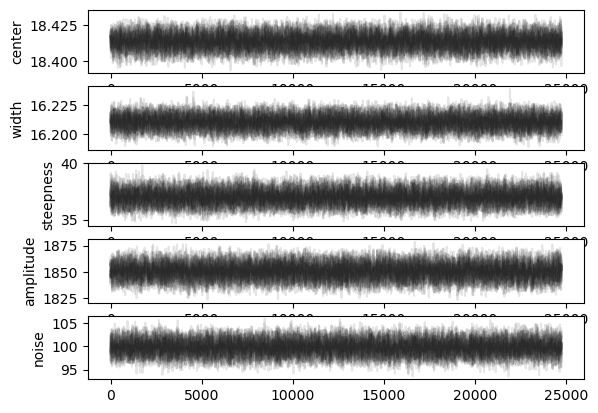

In [63]:
autocorr_time = sampler.get_autocorr_time()
chain = sampler.get_chain(discard=int(np.max(autocorr_time*4)))
for dim_n in range(chain.shape[2]):
    ax = plt.subplot(chain.shape[2], 1, dim_n + 1)
    ax.set_ylabel(param_labels[dim_n])
    # ax.axvline(autocorr_time[dim_n])
    for walker_n in range(chain.shape[1]):
        plt.plot(chain[:, walker_n, dim_n], c='black', alpha=0.1)

/home/andres/anaconda3/envs/phys4450/lib/python3.14/site-packages/arviz/__init__.py:39: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


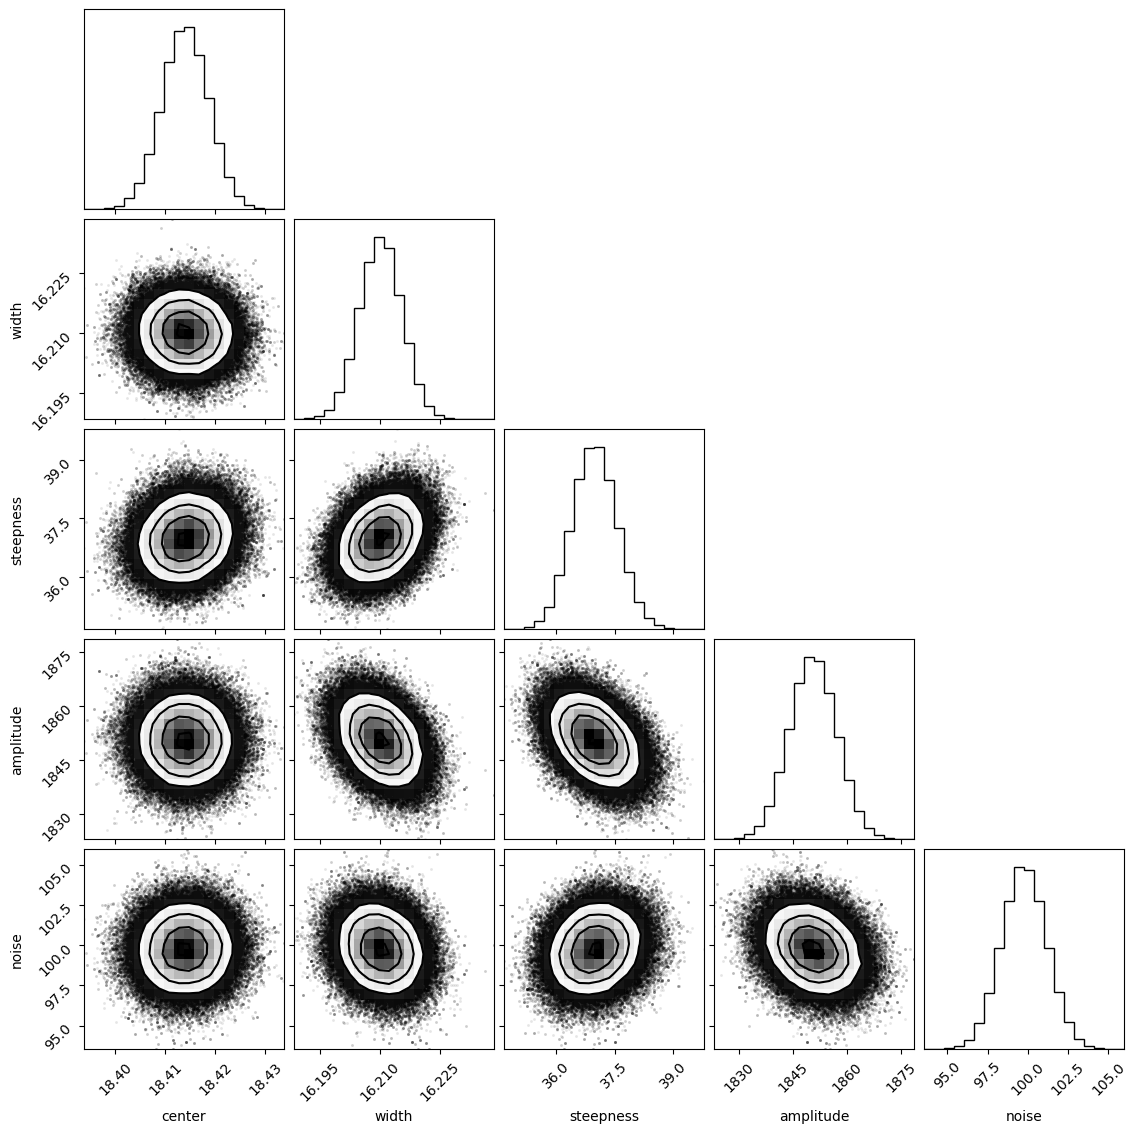

In [40]:
import corner


corner.corner(sampler.get_chain(discard=int(np.max(autocorr_time*4)), flat=True), labels=param_labels);

In [58]:
chain = sampler.get_chain(flat=True, discard=int(np.max(autocorr_time*4)))
results = pd.DataFrame(
    {
        "Median Value": np.median(chain, axis = 0),
        "2sigma uncertainty": np.sqrt(np.diag(np.cov(chain.T))) * 2
    },
    index=param_labels
)
results

,Median Value,2sigma uncertainty
center,18.413969,0.009304
width,16.210229,0.010466
steepness,36.982397,1.147700
amplitude,1850.485904,13.039404
noise,99.756316,2.801427


In [60]:
results["2sigma uncertainty"].values

array([9.30355380e-03, 1.04660001e-02, 1.14769965e+00, 1.30394044e+01,
       2.80142739e+00])

In [61]:
results["2sigma uncertainty"]/results["Median Value"]

center       0.000505
width        0.000646
steepness    0.031034
amplitude    0.007046
noise        0.028083
dtype: float64